In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [6]:
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
models = {
    "DT (Overfit)": DecisionTreeClassifier(max_depth=None, random_state=42),
    "RF (Good Fit)": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "RF (Shallow Trees)": RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42),
    "RF(More Trees)": RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42)
}

In [9]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()

C:\Users\Vishal\AppData\Local\Temp\ipykernel_24932\1837233100.py:14: UserWarning: The figure layout has changed to tight
C:\Users\Vishal\AppData\Local\Temp\ipykernel_24932\1837233100.py:14: UserWarning: The figure layout has changed to tight
C:\Users\Vishal\AppData\Local\Temp\ipykernel_24932\1837233100.py:14: UserWarning: The figure layout has changed to tight
C:\Users\Vishal\AppData\Local\Temp\ipykernel_24932\1862483185.py:9: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from current font.
C:\Users\Vishal\AppData\Local\Temp\ipykernel_24932\1862483185.py:9: UserWarning: The figure layout has changed to tight
C:\Users\Vishal\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from current font.


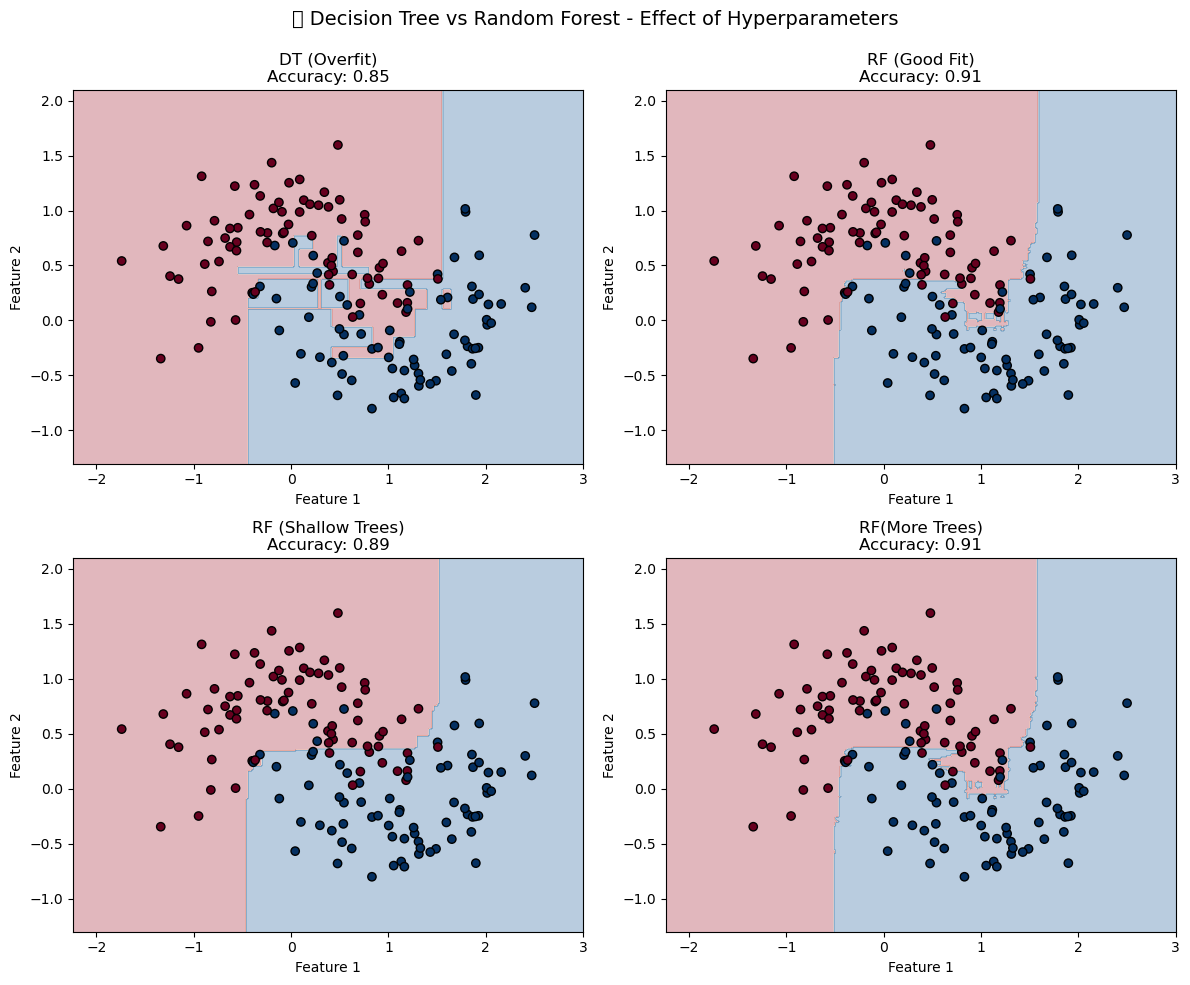

In [10]:
plt.figure(figsize=(12, 10))
for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    plt.subplot(2, 2, i)
    plot_decision_boundary(model, X_test, y_test, f"{name}\nAccuracy: {acc:.2f}")
plt.suptitle("Decision Tree vs Random Forest - Effect of Hyperparameters", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import randint

In [2]:
df = pd.read_csv("loan_default.csv")
df_encoded = pd.get_dummies(df, columns=["EmploymentType", "Region"], drop_first=True)


In [5]:
df_encoded

,Age,Income,LoanAmount,Tenure,InterestRate,NumDependents,CreditScore,PreviousDefaults,Default,EmploymentType_Self-employed,Region_Semiurban,Region_Urban
0,59,26302,680585,72,18.20,1,725,2,1,True,True,False
1,49,82506,710902,12,12.44,2,378,0,0,False,False,False
2,35,56157,272084,72,9.25,2,481,0,0,False,False,False
3,63,69917,539536,12,9.48,2,798,2,0,True,True,False
4,28,111646,110428,72,8.58,4,370,0,0,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,53,78037,768675,12,11.25,4,637,0,0,True,True,False
996,22,104818,932487,12,16.35,0,422,1,1,True,False,True
997,34,21548,252416,12,8.08,4,746,1,0,False,True,False
998,60,131981,974300,36,9.26,2,590,0,0,True,False,False


In [6]:
X = df_encoded.drop("Default", axis=1)
y = df_encoded["Default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
y_train.shape

(700,)

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Default Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Default Random Forest
Accuracy: 0.9466666666666667
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       187
           1       0.97      0.88      0.93       113

    accuracy                           0.95       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.95      0.95      0.95       300



https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [11]:
param_dist = {
    "n_estimators": randint(200, 500),
    "max_depth": randint(2, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 8),
    "max_features": ['sqrt', 'log2', None]
}


In [14]:
rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
rs.fit(X_train, y_train)

best_rf = rs.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest (Best Hyperparameters)")
print("Best Params:", rs.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned Random Forest (Best Hyperparameters)
Best Params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 4, 'n_estimators': 271}
Accuracy: 0.9566666666666667
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       187
           1       1.00      0.88      0.94       113

    accuracy                           0.96       300
   macro avg       0.97      0.94      0.95       300
weighted avg       0.96      0.96      0.96       300

